# EDA for New Occurrence Data

"pt" = Permian-Triassic = Perm_Trias folder

"gl" = Guadilupian-Ladinian = Guad-Ladin folder

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Permian-Triassic Data


## Loading + Filtering + EDA Occs Data

In [94]:
pt_reptilia_all = pd.read_excel("Perm-Trias/occs_combined/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_All_AF_Tiago_combined.xlsx")
pt_reptilia_terr = pd.read_excel("Perm-Trias/occs_combined/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_terres_AF_Tiago_combined.xlsx")
pt_synapsida = pd.read_excel("Perm-Trias/occs_combined/synapsida_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_AF_Tiago_combined.xlsx")

# gl_reptilia = pd.read_excel("Guad-Ladin/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_terres_MidTria.xlsx")
# gl_synapsida = pd.read_excel("Guad-Ladin/synapsida_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_MidTria.xlsx")

In [95]:
pt_reptilia_all.columns

Index(['occurrence_no', 'occurrence_no_AF', 'id', 'id_seperated', 'expt',
       'Rotated latitude', 'Rotated longitude', 'i_index', 'j_index',
       'Topo. (m)',
       ...
       'geoplate', 'paleoage', 'paleolng', 'paleolat', 'paleomodel2',
       'geoplate2', 'paleoage2', 'paleolng2', 'paleolat2', 'paleomodel3'],
      dtype='object', length=296)

In [96]:

pt_reptilia_all_filtered = pt_reptilia_all[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min', 'Epoch']]
pt_reptilia_terr_filtered = pt_reptilia_terr[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min', 'Epoch']]
pt_synapsida_filtered = pt_synapsida[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min', 'Epoch']]

# Need to add 'id' back in
# gl_reptilia_filtered = gl_reptilia[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min']]
# gl_synapsida_filtered = gl_synapsida[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min']]

In [97]:
list_filtered_dfs = [pt_reptilia_all_filtered, pt_reptilia_terr_filtered, pt_synapsida_filtered]
                        # ,gl_reptilia_filtered, gl_synapsida_filtered]

list_filtered_dfs_names = ['pt_reptilia_all_filtered', 'pt_reptilia_terr_filtered', 'pt_synapsida_filtered']
                        # ,'gl_reptilia_filtered', 'gl_synapsida_filtered']

# write a loop for 0:len(list_filtered_dfs) to print the name of each dataframe and its description
# and the number of missing values in each column
for i in range(len(list_filtered_dfs)):
    print(f"DataFrame: {list_filtered_dfs_names[i]}")
    print(list_filtered_dfs[i].describe())
    print(list_filtered_dfs[i].isna().sum())
    # Check that occurrence_no_AF is the same as occurrence_no, because the former came from Alex's dataset and the latter from Tiago's dataset.
    # If they're the same we know merging the two datasets happened correctly.
    different_rows = list_filtered_dfs[i].loc[list_filtered_dfs[i]['occurrence_no'] != list_filtered_dfs[i]['occurrence_no_AF']]
    length_different_rows = different_rows.shape[0]
    print(f"Number of rows where 'occurrence_no' and 'occurrence_no_AF' are different: {length_different_rows}")


DataFrame: pt_reptilia_all_filtered
               id      age_max      age_min
count  3987.00000  3987.000000  3987.000000
mean   5134.00000   244.115497   234.918219
std    1151.09209    22.017241    24.675819
min    3141.00000   201.400000   199.500000
25%    4137.50000   227.000000   208.500000
50%    5134.00000   242.000000   237.000000
75%    6130.50000   259.510000   251.902000
max    7127.00000   298.900000   293.520000
id                  0
occurrence_no       0
occurrence_no_AF    0
genus               0
age_max             0
age_min             0
Epoch               0
dtype: int64
Number of rows where 'occurrence_no' and 'occurrence_no_AF' are different: 0
DataFrame: pt_reptilia_terr_filtered
                id      age_max      age_min
count  3140.000000  3140.000000  3140.000000
mean   1570.500000   243.411428   233.281573
std     906.584249    21.467100    24.709039
min       1.000000   201.400000   199.500000
25%     785.750000   227.000000   208.500000
50%    1570.50000

In [98]:
# See if there are any non-letters in the 'genus' columns of each dataframe
for i in range(len(list_filtered_dfs)):
    non_letters = list_filtered_dfs[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names[i]}")
        print(f"Non-letter characters found in 'genus': {list_filtered_dfs[i][non_letters]['genus'].unique()}\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered
Non-letter characters found in 'genus': ['new Neotheropoda' 'new Rhynchocephalia' 'Stenoscelida\xa0']

DataFrame: pt_reptilia_terr_filtered
Non-letter characters found in 'genus': ['new Neotheropoda' 'new Rhynchocephalia' 'Stenoscelida\xa0']

DataFrame: pt_synapsida_filtered
Non-letter characters found in 'genus': ['-' 'Bonacynodon ']



In [99]:
# print the rows with non-letter characters in the 'genus' column
for i in range(len(list_filtered_dfs)):
    non_letters = list_filtered_dfs[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names[i]}")
        print(list_filtered_dfs[i][non_letters])
        print("\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered
       id occurrence_no occurrence_no_AF                genus  age_max  \
974  4115          N363             N363     new Neotheropoda    227.0   
975  4116          N364             N364  new Rhynchocephalia    227.0   
979  4120          N503             N503        Stenoscelida     227.0   

     age_min           Epoch  
974    208.5  Upper Triassic  
975    208.5  Upper Triassic  
979    208.5  Upper Triassic  


DataFrame: pt_reptilia_terr_filtered
      id occurrence_no occurrence_no_AF                genus  age_max  \
968  969          N363             N363     new Neotheropoda    227.0   
969  970          N364             N364  new Rhynchocephalia    227.0   
973  974          N503             N503        Stenoscelida     227.0   

     age_min           Epoch  
968    208.5  Upper Triassic  
969    208.5  Upper Triassic  
973    208.5  Upper Triassic  


DataFrame: pt_synapsida_filtered
        id occurrence_no occurrence_no_AF         ge

In [100]:
# Fixing those

# Make a copy of the filtered dataframes to avoid modifying the original ones
pt_reptilia_all_filtered_spellchecked = pt_reptilia_all_filtered.copy()
pt_reptilia_terr_filtered_spellchecked = pt_reptilia_terr_filtered.copy()
pt_synapsida_filtered_spellchecked = pt_synapsida_filtered.copy()

# Now perform all the cleaning

# Strip the ending space from row with index 979 in pt_reptilia_all_filtered in 'genus' column
pt_reptilia_all_filtered_spellchecked.at[979, 'genus'] = pt_reptilia_all_filtered_spellchecked.at[979, 'genus'].strip()

# Strip the ending space from row with index 973 in pt_reptilia_terr_filtered in 'genus' column
pt_reptilia_terr_filtered_spellchecked.at[973, 'genus'] = pt_reptilia_terr_filtered_spellchecked.at[973, 'genus'].strip()

# Strip the ending space from row with index 2685 and 2686 in pt_synapsida_filtered in 'genus' column
pt_synapsida_filtered_spellchecked.at[2685, 'genus'] = pt_synapsida_filtered_spellchecked.at[2685, 'genus'].strip()
pt_synapsida_filtered_spellchecked.at[2686, 'genus'] = pt_synapsida_filtered_spellchecked.at[2686, 'genus'].strip()

# Delete row with index 370 from pt_synapsida_all_filtered
pt_synapsida_filtered_spellchecked = pt_synapsida_filtered_spellchecked.drop(370)



In [101]:
# Check again

list_filtered_dfs_spellchecked = [pt_reptilia_all_filtered_spellchecked, pt_reptilia_terr_filtered_spellchecked, pt_synapsida_filtered_spellchecked]
list_filtered_dfs_names_spellchecked = ['pt_reptilia_all_filtered_spellchecked', 'pt_reptilia_terr_filtered_spellchecked', 'pt_synapsida_filtered_spellchecked']

# print the rows with non-letter characters in the 'genus' column
for i in range(len(list_filtered_dfs_spellchecked)):
    non_letters = list_filtered_dfs_spellchecked[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names_spellchecked[i]}")
        print(list_filtered_dfs_spellchecked[i][non_letters])
        print("\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names_spellchecked[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered_spellchecked
       id occurrence_no occurrence_no_AF                genus  age_max  \
974  4115          N363             N363     new Neotheropoda    227.0   
975  4116          N364             N364  new Rhynchocephalia    227.0   

     age_min           Epoch  
974    208.5  Upper Triassic  
975    208.5  Upper Triassic  


DataFrame: pt_reptilia_terr_filtered_spellchecked
      id occurrence_no occurrence_no_AF                genus  age_max  \
968  969          N363             N363     new Neotheropoda    227.0   
969  970          N364             N364  new Rhynchocephalia    227.0   

     age_min           Epoch  
968    208.5  Upper Triassic  
969    208.5  Upper Triassic  


DataFrame: pt_synapsida_filtered_spellchecked - No non-letter characters found in 'genus'.



## Ages Visualization (Range Plots)

In [102]:
# Custom function to plot age RANGE (x) frequency (y) with log scale
def range_plot(df, df_name):
    # # Count the frequency of each age range
    # df['range'] = df.apply(lambda row: (row['age_max'], row['age_min']), axis=1)
    # frequency = df['range'].value_counts().sort_index()

    # Determine which column names are present
    age_max_col = 'age_max'
    age_min_col = 'age_min' 
    
    # Count the frequency of each age range
    df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)
    frequency = df['range'].value_counts().sort_index()
    # Create the plot
    fig, ax = plt.subplots(figsize=(12,6))

    # Plot each range as a horizontal line with log-transformed y-values
    for (age_min, age_max), count in frequency.items():
        ax.plot([age_min, age_max], [np.log(count)] * 2, 'b-', linewidth=2)

    # Set the axis labels and title
    ax.set_xlabel('Age')
    ax.set_ylabel('Log(Frequency)')
    ax.set_title(f'{df_name} Age Range Frequency Plot (Log Scale)')

    # Get the x-axis limits
    x_min, x_max = ax.get_xlim()

    # Create ticks for every 1 unit
    ticks = np.arange(np.ceil(x_min), np.floor(x_max) + 1, 1)
    ax.set_xticks(ticks)

    # Create labels for every 5 units
    labels = [str(int(x)) if x % 5 == 0 else '' for x in ticks]
    ax.set_xticklabels(labels)

    # Invert the x-axis
    ax.invert_xaxis()

    # Add horizontal line at y=log(10)
    ax.axhline(y=np.log(10), color='r', linestyle='--', linewidth=2)

    # Customize y-axis ticks to show original frequency values
    y_ticks = ax.get_yticks()
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{np.exp(y):.0f}' for y in y_ticks])

    # Add vertical lines at the time-bin x-values
    vertical_lines = [290.1, 283.5, 273, 264.3, 259.5, 252, 247, 242, 237, 227, 217, 208]
    for vline in vertical_lines:
        ax.axvline(x=vline, color='g', linestyle='--', linewidth=1)

    # Show the plot
    plt.tight_layout()
    plt.show()
    plt.close()

    return fig

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_23540\1700410389.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


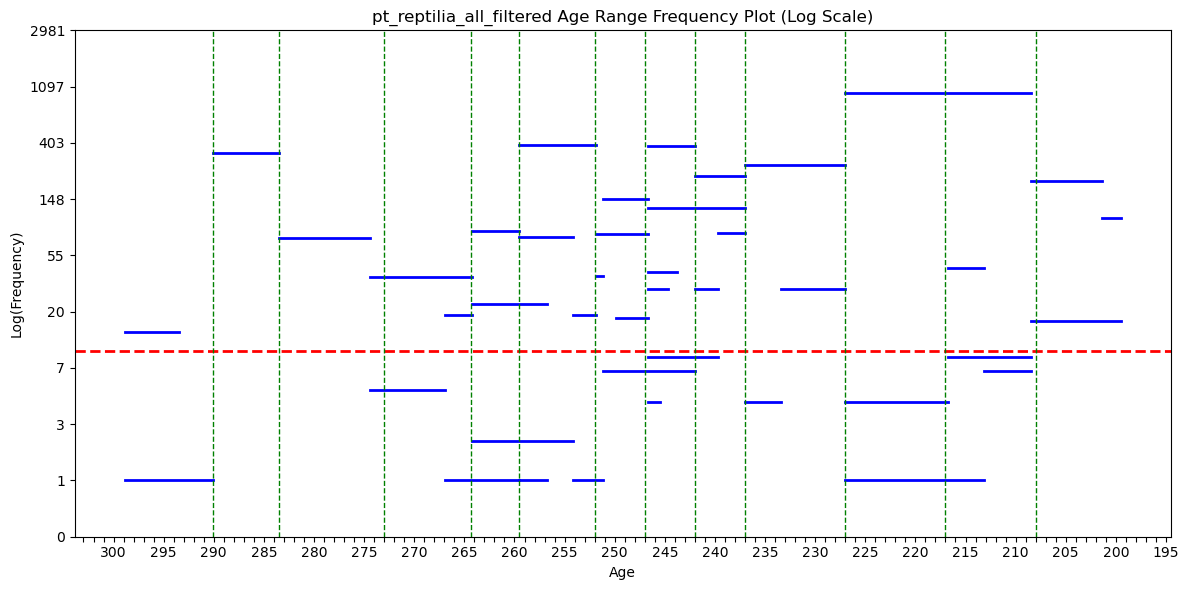

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_23540\1700410389.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


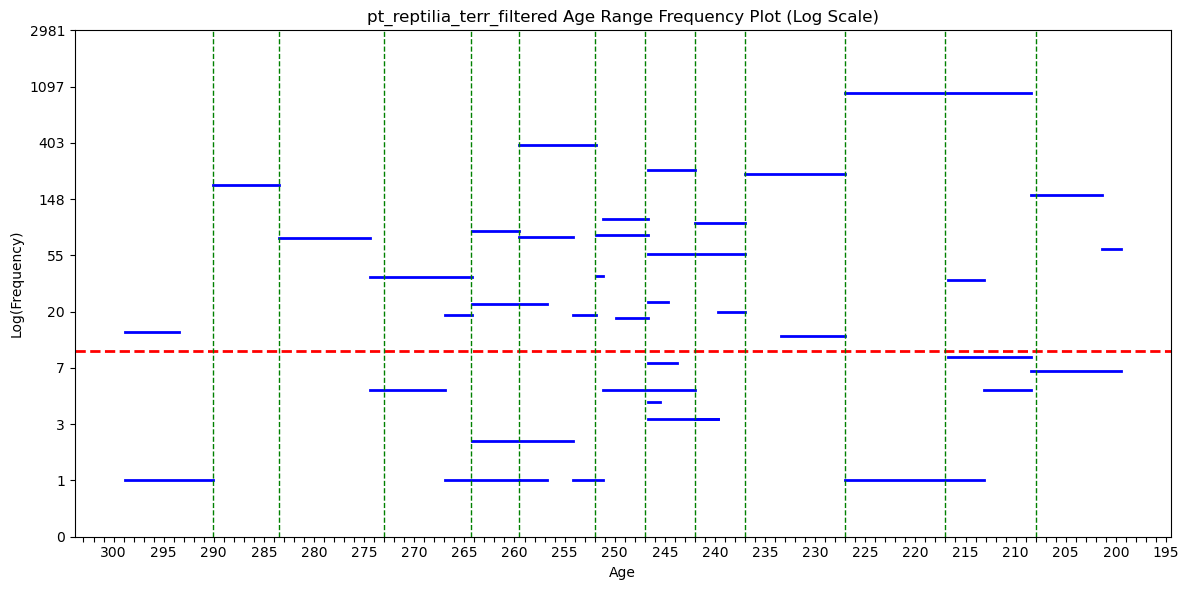

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_23540\1700410389.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


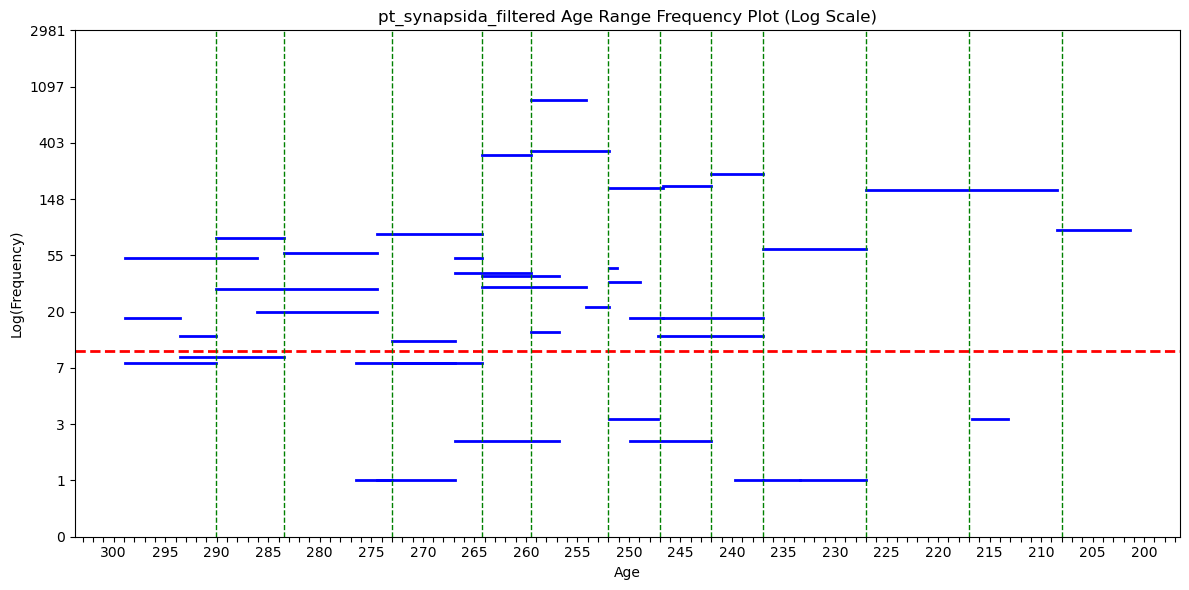

In [103]:
for i in range(len(list_filtered_dfs)):
    range_plot(list_filtered_dfs[i], list_filtered_dfs_names[i])

## Saving Occs off as PyRate Input .txts

In [104]:
cols_dict = {'genus':'Species', 'age_max':'max_age', 'age_min':'min_age'}

pt_reptilia_all_filtered_spellchecked_renamed = pt_reptilia_all_filtered_spellchecked[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_reptilia_all_filtered_spellchecked_renamed['Status'] = "extinct"
# Putting the columns in the right order
pt_reptilia_all_filtered_spellchecked_renamed = pt_reptilia_all_filtered_spellchecked_renamed[['Species', 'Status', 'min_age', 'max_age']]

pt_reptilia_terr_filtered_spellchecked_renamed = pt_reptilia_terr_filtered_spellchecked[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_reptilia_terr_filtered_spellchecked_renamed['Status'] = "extinct"
# Putting the columns in the right order
pt_reptilia_terr_filtered_spellchecked_renamed = pt_reptilia_terr_filtered_spellchecked_renamed[['Species', 'Status', 'min_age', 'max_age']]

pt_synapsida_filtered_spellchecked_renamed = pt_synapsida_filtered_spellchecked[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_synapsida_filtered_spellchecked_renamed['Status'] = "extinct"
# Putting the columns in the right order
pt_synapsida_filtered_spellchecked_renamed = pt_synapsida_filtered_spellchecked_renamed[['Species', 'Status', 'min_age', 'max_age']]

In [105]:
# Only the synapsida dataset should have one fewer row
# All other datasets should have the same number of rows as before
pt_reptilia_all_filtered.shape[0], pt_reptilia_all_filtered_spellchecked_renamed.shape[0], pt_reptilia_terr_filtered.shape[0], pt_reptilia_terr_filtered_spellchecked_renamed.shape[0], pt_synapsida_filtered.shape[0], pt_synapsida_filtered_spellchecked_renamed.shape[0]

(3987, 3987, 3140, 3140, 3185, 3184)

In [106]:
pt_reptilia_all_filtered_spellchecked_renamed.isna().sum(), pt_reptilia_terr_filtered_spellchecked_renamed.isna().sum(), pt_synapsida_filtered_spellchecked_renamed.isna().sum()

(Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64)

In [88]:
pt_reptilia_all_filtered_spellchecked_renamed.head(), pt_reptilia_terr_filtered_spellchecked_renamed.head(), pt_synapsida_filtered_spellchecked_renamed.head()

(          Species   Status  min_age  max_age
 0     Icarosaurus  extinct    208.5    227.0
 1        Rutiodon  extinct    208.5    227.0
 2  Trilophosaurus  extinct    208.5    227.0
 3     Postosuchus  extinct    208.5    227.0
 4     Postosuchus  extinct    208.5    227.0,
       Species   Status  min_age  max_age
 0  Vancleavea  extinct    208.5    227.0
 1  Vancleavea  extinct    208.5    227.0
 2  Vancleavea  extinct    208.5    227.0
 3  Vancleavea  extinct    208.5    227.0
 4  Vancleavea  extinct    208.5    227.0,
         Species   Status  min_age  max_age
 0    Dimetrodon  extinct    286.1    298.9
 1    Ophiacodon  extinct    286.1    298.9
 2   Sphenacodon  extinct    286.1    298.9
 3  Edaphosaurus  extinct    286.1    298.9
 4    Ophiacodon  extinct    286.1    298.9)

In [89]:
# Check data types
print(pt_reptilia_all_filtered_spellchecked_renamed.dtypes)
print(pt_reptilia_terr_filtered_spellchecked_renamed.dtypes)
print(pt_synapsida_filtered_spellchecked_renamed.dtypes)

Species     object
Status      object
min_age    float64
max_age    float64
dtype: object
Species     object
Status      object
min_age    float64
max_age    float64
dtype: object
Species     object
Status      object
min_age    float64
max_age    float64
dtype: object


In [90]:
# Check if min_age is ever greater than max_age
print("Checking if min_age is ever greater than max_age in pt_reptilia_all_filtered_spellchecked_renamed:")
print((pt_reptilia_all_filtered_spellchecked_renamed['min_age'] > pt_reptilia_all_filtered_spellchecked_renamed['max_age']).any())
print("Checking if min_age is ever greater than max_age in pt_reptilia_terr_filtered_spellchecked_renamed:")
print((pt_reptilia_terr_filtered_spellchecked_renamed['min_age'] > pt_reptilia_terr_filtered_spellchecked_renamed['max_age']).any())
print("Checking if min_age is ever greater than max_age in pt_synapsida_filtered_spellchecked_renamed:")
print((pt_synapsida_filtered_spellchecked_renamed['min_age'] > pt_synapsida_filtered_spellchecked_renamed['max_age']).any())


Checking if min_age is ever greater than max_age in pt_reptilia_all_filtered_spellchecked_renamed:
False
Checking if min_age is ever greater than max_age in pt_reptilia_terr_filtered_spellchecked_renamed:
False
Checking if min_age is ever greater than max_age in pt_synapsida_filtered_spellchecked_renamed:
False


In [92]:
# Saving all off as .txt's
pt_reptilia_all_filtered_spellchecked_renamed.to_csv("Perm-Trias/pt_reptilia_all_filtered_spellchecked_renamed.txt", sep="\t", index=False)
pt_reptilia_terr_filtered_spellchecked_renamed.to_csv("Perm-Trias/pt_reptilia_terr_filtered_spellchecked_renamed.txt", sep="\t", index=False)
pt_synapsida_filtered_spellchecked_renamed.to_csv("Perm-Trias/pt_synapsida_filtered_spellchecked_renamed.txt", sep="\t", index=False)


# Guadalupian-Ladinian Data

In [108]:
gl_reptilia_terr = pt_reptilia_terr_filtered_spellchecked.copy()
gl_synapsida = pt_synapsida_filtered_spellchecked.copy()

gl_reptilia_terr.head(), gl_synapsida.head()

(   id occurrence_no occurrence_no_AF       genus  age_max  age_min  \
 0   1        557171           557171  Vancleavea    227.0    208.5   
 1   2        812265           812265  Vancleavea    227.0    208.5   
 2   3        837001           837001  Vancleavea    227.0    208.5   
 3   4        837005           837005  Vancleavea    227.0    208.5   
 4   5        837007           837007  Vancleavea    227.0    208.5   
 
            Epoch  
 0  Late Triassic  
 1  Late Triassic  
 2  Late Triassic  
 3  Late Triassic  
 4  Late Triassic  ,
      id occurrence_no occurrence_no_AF         genus  age_max  age_min  \
 0  7128       1547022          1547022    Dimetrodon    298.9    286.1   
 1  7129       1547014          1547014    Ophiacodon    298.9    286.1   
 2  7130       1547013          1547013   Sphenacodon    298.9    286.1   
 3  7131       1491393          1491393  Edaphosaurus    298.9    286.1   
 4  7132       1340561          1340561    Ophiacodon    298.9    286.1   
 

In [110]:
# We want to filter for rows that contain only certain values in the "Epoch" column

epochs = ['Guadalupian', 'Lopingian', 'Early Triassic', 'Middle Triassic']

gl_reptilia_terr_epochs = gl_reptilia_terr[gl_reptilia_terr['Epoch'].isin(epochs)]
gl_synapsida_epochs = gl_synapsida[gl_synapsida['Epoch'].isin(epochs)]

gl_reptilia_terr.shape[0], gl_reptilia_terr_epochs.shape[0], gl_synapsida.shape[0], gl_synapsida_epochs.shape[0]    


(3140, 1345, 3184, 2574)

In [111]:
# Filter to columns

cols_dict = {'genus':'Species', 'age_max':'max_age', 'age_min':'min_age'}

gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_reptilia_terr_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

gl_synapsida_epochs_filtered = gl_synapsida_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_synapsida_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_synapsida_epochs_filtered = gl_synapsida_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

In [112]:
gl_reptilia_terr_epochs_filtered.shape[0], gl_synapsida_epochs_filtered.shape[0]

(1345, 2574)

In [113]:
gl_reptilia_terr_epochs_filtered.head(), gl_synapsida_epochs_filtered.head()

(           Species   Status  min_age  max_age
 1056  Rhombopholis  extinct    237.0    246.7
 1057    Langeronyx  extinct    237.0    246.7
 1058  Teratosaurus  extinct    237.0    246.7
 1059   Macrocnemus  extinct    237.0    246.7
 1060   Macrocnemus  extinct    237.0    246.7,
              Species   Status  min_age  max_age
 281  Parabradysaurus  extinct    266.9    276.5
 282  Parabradysaurus  extinct    266.9    276.5
 283       Kamagorgon  extinct    266.9    276.5
 284       Kamagorgon  extinct    266.9    276.5
 285      Microsyodon  extinct    266.9    276.5)

In [114]:
gl_reptilia_terr_epochs_filtered.describe(), gl_synapsida_epochs_filtered.describe()

(           min_age      max_age
 count  1345.000000  1345.000000
 mean    248.402201   254.177386
 std       7.230530     7.931046
 min     237.000000   239.700000
 25%     242.000000   246.700000
 50%     251.200000   251.902000
 75%     251.902000   259.510000
 max     266.900000   274.400000,
            min_age      max_age
 count  2574.000000  2574.000000
 mean    251.945916   257.576842
 std       7.274871     7.716511
 min     237.000000   239.700000
 25%     246.700000   251.902000
 50%     254.140000   259.510000
 75%     254.140000   259.510000
 max     273.010000   276.500000)

In [115]:
gl_reptilia_terr_epochs_filtered.isna().sum(), gl_synapsida_epochs_filtered.isna().sum()

(Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64)

In [116]:
# Saving them off as .txt's
gl_reptilia_terr_epochs_filtered.to_csv("Guad-Ladin/gl_reptilia_terr_epochs_filtered.txt", sep="\t", index=False)
gl_synapsida_epochs_filtered.to_csv("Guad-Ladin/gl_synapsida_epochs_filtered.txt", sep="\t", index=False)